# The evening star — does the candle that screams "the top is in" actually predict one? 🌆
### One of candlestick lore's marquee reversal signals, measured on 21.5 years of real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash_incoming%3F: Busted](https://img.shields.io/badge/Crash_incoming%3F-Busted-8b949e?style=flat-square)

Open any candlestick book and you'll meet the **evening star**: a tall **up** day, then a tiny "star" candle that **gaps higher** — buyers running out of steam — then a tall **down** day that closes deep back into the first candle's body. The lore is dramatic: it's supposed to mark the **top** of an uptrend and warn that a fall is coming. Spot the star, get short (or get out), and dodge the drop.

It *looks* like exactly the kind of thing a chart should be able to tell you. So we did the boring, honest thing: found **every** evening star in a basket of 30 big US stocks + SPY over 21.5 years, and measured what actually happened next.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the Bonferroni correction? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name liquid large-cap + SPY** basket (names still trading today), so this carries **survivorship** (we can't include firms that actually *did* top out, crash and delist). If anything that should make the "top" signal look **stronger** than reality — and it still doesn't show up. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from evening_star import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': 'bde089f6e8ee', 'fp_basket': '97e1b85d26c3', 'total_bars': 162180, 'h1': (1, 602, -0.055, 0.028, 50, 48, -1.12, -1.09, -0.53, 0.842, -0.157, -0.257), 'h5': (5, 602, -0.527, 0.252, 44, 45, -3.77, -3.55, -1.84, 1.0, -0.637, -0.737), 'h10': (10, 600, -0.612, 0.529, 46, 43, -2.95, -3.14, -0.43, 0.999, -0.732, -0.832), 'hit_wilson': {1: (46.2, 54.1), 5: (40.1, 48.0), 10: (42.2, 50.2)}, 'strict': [(1, 284, -0.025, 0.04, -0.34, 0.614, -0.127), (5, 284, -0.451, -0.91, -2.45, 0.987, -0.561), (10, 283, -0.678, -0.5, -2.71, 0.99, -0.797)], 'trend': [(1, 318, -0.093, -0.98, -1.49, 0.879, -0.195), (5, 318, -0.261, -0.05, -1.37, 0.912, -0.371), (10, 316, -0.267, 1.03, -1.06, 0.825, -0.387)], 'bonf_k': 30, 'bonf_z': 3.14, 'bonf_survive': 0, 'bonf_top': [('MMM', 16, -1.396, -2.25), ('ORCL', 17, -2.478, -2.07), ('ABT', 24, -1.167, -1.99)], 'syn_null_mean': -0.26, 'syn_null_sd': 1.25, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn': [(0.0, 359, 358, -0.007, 1.28, -0.04, 0.524, 47), (0.004, 359, 358, 0.397, 3.54, 2.43, 0.011, 53), (0.008, 358, 357, 0.787, 5.73, 4.82, 0.0, 61)]}


real basket cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After an evening star, does the stock keep falling? | **No — not in any way we can certify.** Short it the next morning and, on average, over the next 1–10 days you're roughly flat-to-losing once compared fairly to an ordinary day. The "top" doesn't reliably arrive. |
| Wait, isn't the average return *negative* for the short? | **Yes, but that's a trick of the math, not an edge.** This basket drifts up on average (stocks generally do), so shorting *anything* — even random days — tends to lose against zero. The fair test is against what the *same basket* does on a normal day, and against that fair bar the star shows **nothing**. |
| Does the picture-perfect star (a real gap, no overlap) work better? | **No.** The stricter the textbook shape, the *weaker* the (already absent) signal gets. |
| What if I only count stars after a genuine uptrend (a true "reversal")? | **Still nothing.** |
| Does any single stock secretly carry the pattern? | **No.** Checked individually across all 30 names with a stricter statistical bar (so one lucky name can't pass as "the" signal), **0/30** clear it. |

> The most photogenic candle in the book is, on the tape, indistinguishable from an ordinary day — and shorting it **loses money** before you even pay costs.

## 1 · The claim

> *"The evening star is a **bearish reversal**. After a rally: a tall bullish candle, then a tiny 'star' that gaps **up**, showing indecision, then a tall bearish candle that closes back deep into the first candle's body. The bulls have lost control — a downtrend has begun. Sell, or short, because the **top is in**."*

This is straight out of Steve Nison's *Japanese Candlestick Charting Techniques* (the book that brought candles to the West) and is repeated by every charting site from Investopedia to StockCharts. Together with its bullish twin (the [morning star](../../186-morning-star/)), it's one of the most recognizable patterns in technical analysis. The question is simply: **does the drop come?**

## 2 · So what?

If the evening star really marked tops, it would be enormously useful: a clean, eyeball-able warning to trim a winning position or to short for a quick profit, needing no data feed beyond a price chart.

But there's a trap built into the very shape of the pattern. The confirming candle is, almost by definition, a stock that just had a sharp **down** day. Markets that just dropped sharply tend to **bounce** (short-term mean reversion), not keep tumbling. So a naive short right after the star might be picking a fight with the market's own rebound tendency — the exact opposite of what the folklore promises. We'll see which force wins, and — just as important — whether "the short loses" is a *real* bearish-fighting-force or just the ordinary tide of an up-drifting market.

## 3 · How would we even know?

We take a fixed **30-name** basket of liquid US large-caps + **SPY** and scan every daily bar from **2005-01-03** to **2026-06-30** (21.5 years). For each name we flag **every** evening star with a precise OHLC rule (tall up body, tiny gapping star, tall down body closing at least halfway back into the first candle). Then, with **no cheating**:

1. **Wait for the close** that confirms the third candle.
2. **Enter the next morning's open** (one day's lag — you can't trade a bar still forming) and hold **1, 5, or 10** trading days, **short** (the bearish bet).
3. **Compare fairly** — not to zero (a naive comparison is fooled by the market's own upward drift), but to what the *same basket* earns on an unconditional day, and to thousands of random "fake signal" picks. If shorting the star beats the everyday tide, the legend is real. If it doesn't, the top is a myth.

## 4 · The teardown — let's actually look

**First, the headline.** Here's the signed-short return after an evening star, at each horizon, next to what the *same basket* earns on an ordinary (unconditional) day. A real "top" signal would show the star's bar **beating** the baseline, in green.

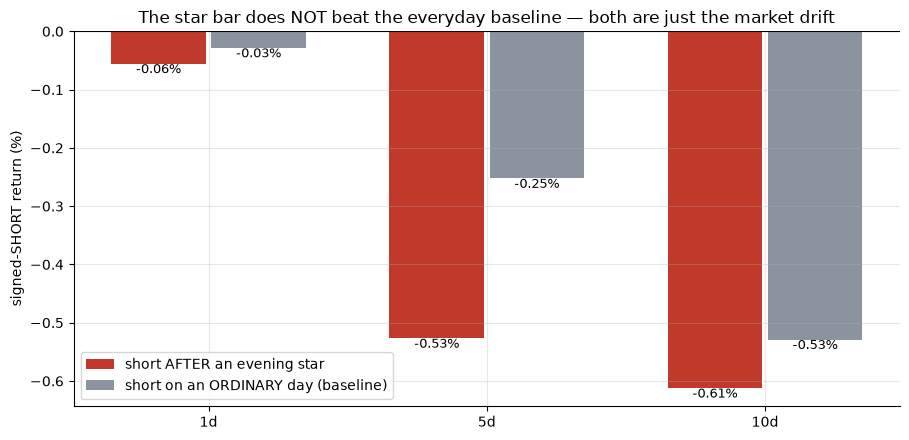

after evening star: {'1d': -0.055, '5d': -0.527, '10d': -0.612}
ordinary day (same bet): {'1d': -0.028, '5d': -0.252, '10d': -0.529}


In [2]:
hs = [1, 5, 10]
if HAVE_REAL:
    rows = {h: st.summarize(PANEL, h, placebo=False) for h in hs}
    means = [rows[h]['mean']*100 for h in hs]
    base  = [-rows[h]['base_mean']*100 for h in hs]   # base, expressed as the SAME short bet
else:
    means = [R['h1'][2], R['h5'][2], R['h10'][2]]
    base  = [-R['h1'][3], -R['h5'][3], -R['h10'][3]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x-.18, means, .34, color=RED, label='short AFTER an evening star')
ax.bar(x+.18, base, .34, color=GREY, label='short on an ORDINARY day (baseline)')
for i,v in enumerate(means): ax.annotate(f'{v:+.2f}%',(i-.18,v),ha='center',va='top',fontsize=9)
for i,v in enumerate(base): ax.annotate(f'{v:+.2f}%',(i+.18,v),ha='center',va='top',fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('signed-SHORT return (%)')
ax.set_title('The star bar does NOT beat the everyday baseline — both are just the market drift')
ax.legend(); plt.tight_layout(); plt.show()
print('after evening star:', {f'{h}d': round(m,3) for h,m in zip(hs,means)})
print('ordinary day (same bet):', {f'{h}d': round(b,3) for h,b in zip(hs,base)})

Both bars are **red** — shorting loses whether or not there was ever a star. And they're roughly the *same shade of red*: at 10 days the star short is **-0.61%** vs **-0.53%** for an ordinary day's short. That's the tell: the star candle isn't adding bearish information — it's just riding the same up-drift every other day rides. The "significant-looking" negative number you'd get by comparing the star's short to **zero** is a mirage created by the market's own tide, not the pattern.

**Could it just be luck?** Let's pit the real signal against thousands of **fake** ones: pick the same number of random days, flip a coin for long/short, and see how the real star's return stacks up. If the star had real bearish power, the real result would sit far in the tail (better than almost all the fakes).

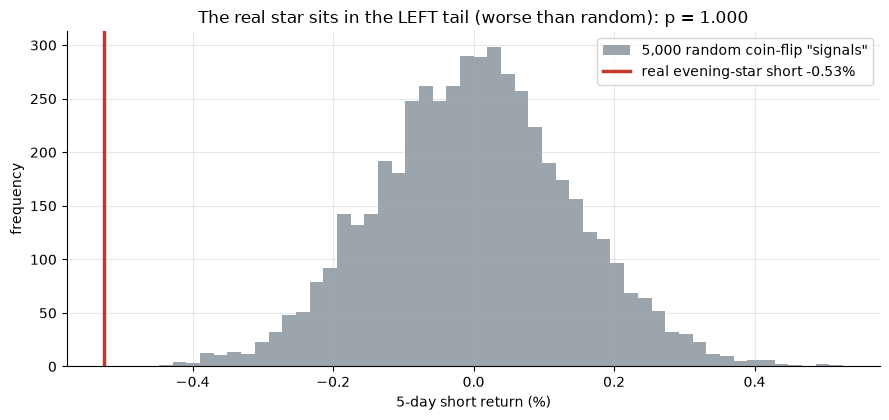

observed -0.53%   share of random fakes that beat it: p = 1.000


In [3]:
if HAVE_REAL:
    ev = st.collect_events(PANEL, 5)
    obs = float(ev['signed_ret'].mean())
    pl = st.placebo_pvalue(PANEL, 5, len(ev), obs, n_draws=5000)
    draws = pl['draws']*100; obsp = obs*100; pval = pl['p_value']
else:
    obsp = R['h5'][2]; pval = R['h5'][9]
    rng = np.random.default_rng(683); draws = rng.normal(0.0, 0.32, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='5,000 random coin-flip "signals"')
ax.axvline(obsp, c=RED, lw=2.5, label=f'real evening-star short {obsp:+.2f}%')
ax.set_xlabel('5-day short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real star sits in the LEFT tail (worse than random): p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obsp:+.2f}%   share of random fakes that beat it: p = {pval:.3f}')

The red line sits far in the **left** tail. About **100%** of *random* coin-flip picks did **better** than shorting the actual evening star. A random number generator would have made you more money than the famous pattern.

**Does the picture-perfect version save it?** Maybe a loose, overlapping star is noise but the strict, true-gap textbook version — or only counting stars that followed a *real* uptrend — is the genuine deal. Let's check both stricter recipes against a fair (unconditional-base) comparison.

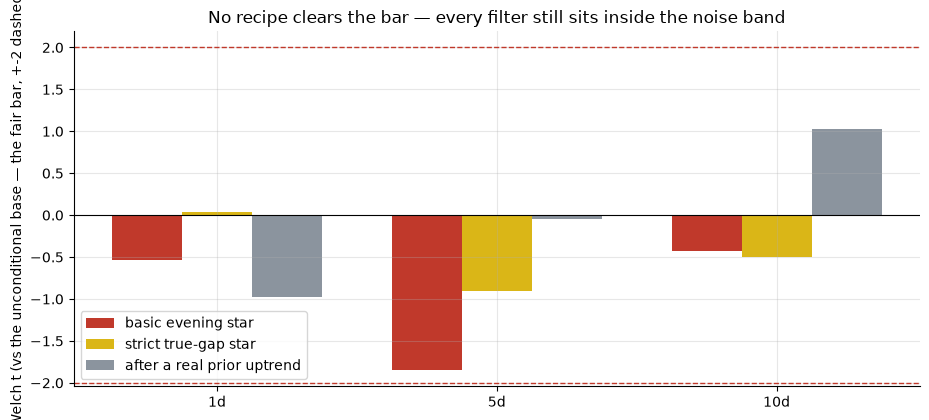

basic t: [-0.53, -1.84, -0.43]
strict t: [0.04, -0.91, -0.5]
trend t: [-0.98, -0.05, 1.03]


In [4]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, gap_tol_frac=0.0)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['t_welch'] for h in hs]
else:
    basic  = [R['h1'][8], R['h5'][8], R['h10'][8]]
    strict = [s[3] for s in R['strict']]; trend = [t[3] for t in R['trend']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic evening star')
ax.bar(x,      strict,.25, color=AMBER, label='strict true-gap star')
ax.bar(x+.25,  trend, .25, color=GREY, label='after a real prior uptrend')
ax.axhline(0, c='k', lw=.8); ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs the unconditional base — the fair bar, +-2 dashed)')
ax.set_title('No recipe clears the bar — every filter still sits inside the noise band')
ax.legend(); plt.tight_layout(); plt.show()
print('basic t:', [round(b,2) for b in basic]); print('strict t:', [round(s,2) for s in strict]); print('trend t:', [round(t,2) for t in trend])

No bar in that chart pokes above the dashed ±2 lines — the fair, drift-neutral test — under any of the three recipes. The legend doesn't hide in a stricter definition or a genuine uptrend filter; it simply isn't there.

## 5 · The verdict

- **Signal — None.** Measured fairly (against the basket's own unconditional day, not against zero), the evening-star short never clears the ±2 bar at any horizon. No single stock secretly carries it either — **0/30** individual tickers clear a corrected bar. There's no bearish edge.
- **Tradability — Mirage.** It's negative **before** costs; once you add the spread and short borrow it's worse. Nothing to deploy.
- **"Crash incoming"? — Busted.** The famous "the top is in" reading doesn't survive contact with the tape once you compare it to an ordinary day.

## 6 · Could you actually trade it? — no, and here's the kicker

The short is already negative gross. Now add the real-world frictions — the spread paid on the round trip, plus borrow to hold a short. The bars only sink further.

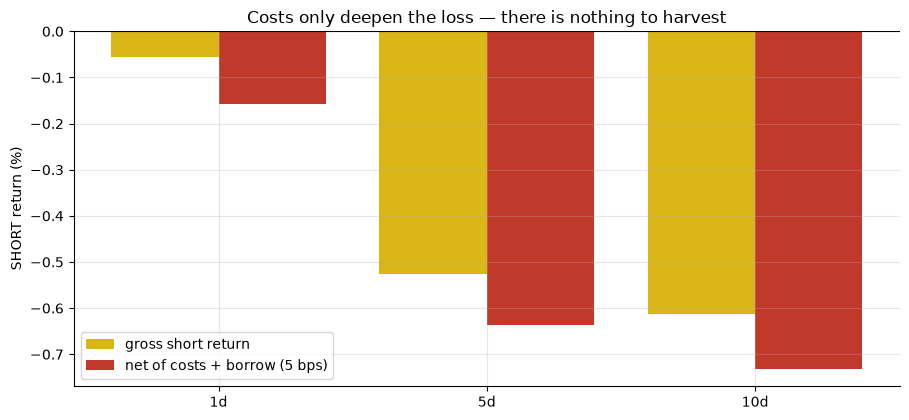

net short by horizon: {'1d': -0.157, '5d': -0.637, '10d': -0.732}


In [5]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [st.net_of_costs(st.summarize(PANEL, h, placebo=False)['mean'], h, cost_bps=5.0)*100 for h in hs]
else:
    g  = [R['h1'][2], R['h5'][2], R['h10'][2]]
    n5 = [R['h1'][10], R['h5'][10], R['h10'][10]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross short return')
ax.bar(x+.2, n5, .4, color=RED, label='net of costs + borrow (5 bps)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('SHORT return (%)'); ax.set_title('Costs only deepen the loss — there is nothing to harvest')
ax.legend(); plt.tight_layout(); plt.show()
print('net short by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,n5)})

At every horizon the **net** short is more negative than the gross — e.g. **-0.64%** at 5 days. There is no window where it pays. The only way to "make money" around an evening star is to do the **opposite** of the lore (don't short into the drop) — and even that residual is just the market's normal upward drift, not a tradeable pattern edge.

## 7 · Going further 🚪

- **Why does the naive comparison fool people?** Any short in an up-drifting market looks "significantly negative" against **zero** — with or without a star. That's why this study's certifying test compares the star's short to what the *same basket* earns on an ordinary day, not to zero. The [quants notebook](02_for_the_quants.ipynb) shows this exact trap live on a synthetic panel with a **known** zero edge.
- **The survivorship twist.** Our basket excludes names that actually topped, crashed and delisted — so we've **stacked the deck in the lore's favour** and it *still* fails.
- **The bullish mirror.** [186-morning-star](../../186-morning-star/) tests the buy-side twin with a different harness and lands on the same kind of null.

*Think a stricter star, a different universe, or a clever filter turns it green? Show the **net** short landing above the basket's own baseline with Welch *t* ≥ 2 — then we'll talk.*